In [ ]:
# ============================
# 1. Setup Environment
# ============================

!pip install tensorflow==2.12.0 scikit-learn matplotlib seaborn pillow gdown --quiet

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow version: 2.12.0


In [ ]:
# ============================
# 2. Data Preparation
# ============================

# Update paths for your local setup
DATA_ROOT = Path(r"D:\python\data\Wonders of World\Wonders of World")
WORK_DIR = Path(r"D:\python\data\wonders_split")
WORK_DIR.mkdir(parents=True, exist_ok=True)


# Helper function to split dataset
def create_train_test_split(src_root, dest_root, train_ratio=0.8, seed=SEED, copy=True):
    np.random.seed(seed)
    src_root = Path(src_root)
    dest_root = Path(dest_root)
    (dest_root / "train").mkdir(parents=True, exist_ok=True)
    (dest_root / "test").mkdir(parents=True, exist_ok=True)

    classes = [d for d in src_root.iterdir() if d.is_dir()]
    for cls in classes:
        files = sorted([f for f in cls.iterdir() if f.is_file()])
        n_train = int(len(files) * train_ratio)
        train_files, test_files = files[:n_train], files[n_train:]

        train_dir = dest_root / "train" / cls.name
        test_dir = dest_root / "test" / cls.name
        train_dir.mkdir(parents=True, exist_ok=True)
        test_dir.mkdir(parents=True, exist_ok=True)

        for f in train_files:
            (shutil.copy2 if copy else shutil.move)(f, train_dir / f.name)
        for f in test_files:
            (shutil.copy2 if copy else shutil.move)(f, test_dir / f.name)
# Split the dataset into train/test folders
create_train_test_split(DATA_ROOT, WORK_DIR, train_ratio=0.8, seed=SEED, copy=True)
print("Train/test split created at:", WORK_DIR)




Train/test split created at: D:\python\data\wonders_split


In [ ]:
# ============================
# 3. Data Generators
# ============================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = WORK_DIR / "train"
test_dir = WORK_DIR / "test"

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)


Found 3072 images belonging to 12 classes.
Found 774 images belonging to 12 classes.


In [ ]:
# ============================
# 4. CNN Model Builder
# ============================

def get_activation_layer(name):
    name = name.lower()
    if name == 'leaky_relu':
        return layers.LeakyReLU(alpha=0.1)
    if name == 'swish':
        return layers.Activation(tf.keras.activations.swish)
    if name == 'elu':
        return layers.Activation('elu')
    return layers.Activation('relu')

def build_cnn(input_shape=(128,128,3), num_classes=NUM_CLASSES, activation='relu', dropout_rate=0.3):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, (3,3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = get_activation_layer(activation)(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(dropout_rate)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = get_activation_layer(activation)(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


In [ ]:
# ============================
# 5. Training Function
# ============================

def get_optimizer(name, lr=1e-3):
    name = name.lower()
    if name == 'sgd':
        return optimizers.SGD(learning_rate=lr, momentum=0.9)
    if name == 'rmsprop':
        return optimizers.RMSprop(learning_rate=lr)
    return optimizers.Adam(learning_rate=lr)

def train_and_evaluate(activation='relu', optimizer_name='adam', lr=1e-3, epochs=25, dropout_rate=0.3, patience=5, exp_name='exp'):
    model = build_cnn((IMG_SIZE[0], IMG_SIZE[1], 3), NUM_CLASSES, activation, dropout_rate)
    opt = get_optimizer(optimizer_name, lr)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    cb_early = callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    cb_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    cb_chk = callbacks.ModelCheckpoint(f'models/{exp_name}_best.h5', save_best_only=True)

    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=epochs,
        callbacks=[cb_early, cb_lr, cb_chk],
        verbose=2
    )
    return model, history


In [ ]:
# ============================
# 6. Evaluation & Visualization
# ============================

def evaluate_model(model, history, class_indices, test_gen, title="Model"):
    # Plot curves
    fig, axs = plt.subplots(1,2, figsize=(14,5))
    axs[0].plot(history.history['accuracy'], label='train_acc')
    axs[0].plot(history.history['val_accuracy'], label='val_acc')
    axs[0].legend(); axs[0].set_title('Accuracy')
    axs[1].plot(history.history['loss'], label='train_loss')
    axs[1].plot(history.history['val_loss'], label='val_loss')
    axs[1].legend(); axs[1].set_title('Loss')
    plt.suptitle(title)
    plt.show()

    preds = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    labels = list(class_indices.keys())
    print(classification_report(y_true, y_pred, target_names=labels))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.show()

In [ ]:
# ============================
# 7. Example Experiment
# ============================

model, history = train_and_evaluate(activation='relu', optimizer_name='adam', lr=1e-3, epochs=20, exp_name='relu_adam')
evaluate_model(model, history, train_gen.class_indices, test_gen, 'ReLU + Adam')


Epoch 1/20


InvalidArgumentError: Graph execution error:

Detected at node 'ArgMax_1' defined at (most recent call last):
    File "<frozen runpy>", line 198, in _run_module_as_main
    File "<frozen runpy>", line 88, in _run_code
    File "C:\Users\Suman Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "C:\Users\Suman Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1043, in launch_instance
      app.start()
    File "C:\Users\Suman Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
      self.io_loop.start()
    File "C:\Users\Suman Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\tornado\platform\asyncio.py", line 195, in start
      self.asyncio_loop.run_forever()
    File "C:\Users\Suman Patel\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py", line 607

IndexError: index 0 is out of bounds for axis 0 with size 0

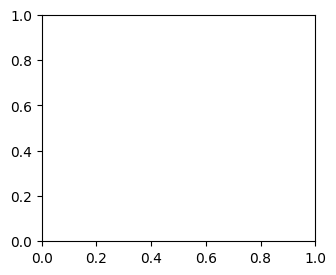

In [ ]:
def show_sample_images(generator, class_indices, num_images=9):
    images, labels = next(generator)
    class_names = list(class_indices.keys())

    plt.figure(figsize=(12, 10))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        label_idx = np.argmax(labels[i])
        plt.title(class_names[label_idx])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function
show_sample_images(train_gen, train_gen.class_indices)


In [ ]:
from pathlib import Path

train_dir = Path(r"D:\python\data\wonders_split\train")
for cls in train_dir.iterdir():
    if cls.is_dir():
        print(cls.name, "→", len(list(cls.glob("*"))), "images")


burj_khalifa → 312 images
chichen_itza → 272 images
christ_the_reedemer → 258 images
eiffel_tower → 312 images
great_wall_of_china → 313 images
machu_pichu → 314 images
pyramids_of_giza → 297 images
roman_colosseum → 315 images
statue_of_liberty → 190 images
stonehenge → 163 images
taj_mahal → 126 images
venezuela_angel_falls → 200 images


In [ ]:
DATA_ROOT = Path(r"D:\python\data\Wonders of World\Wonders of World")
WORK_DIR = Path(r"D:\python\data\wonders_split")

create_train_test_split(DATA_ROOT, WORK_DIR, train_ratio=0.8, seed=SEED, copy=True)


Train/test split created at: D:\python\data\wonders_split


In [ ]:
from pathlib import Path

train_dir = Path(r"D:\python\data\wonders_split\train")
for cls in train_dir.iterdir():
    if cls.is_dir():
        print(cls.name, "→", len(list(cls.glob("*"))), "images")


burj_khalifa → 312 images
chichen_itza → 272 images
christ_the_reedemer → 258 images
eiffel_tower → 312 images
great_wall_of_china → 313 images
machu_pichu → 314 images
pyramids_of_giza → 297 images
roman_colosseum → 315 images
statue_of_liberty → 190 images
stonehenge → 163 images
taj_mahal → 126 images
venezuela_angel_falls → 200 images


In [ ]:
train_gen = train_datagen.flow_from_directory(
    str(WORK_DIR / "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)


Found 3072 images belonging to 12 classes.


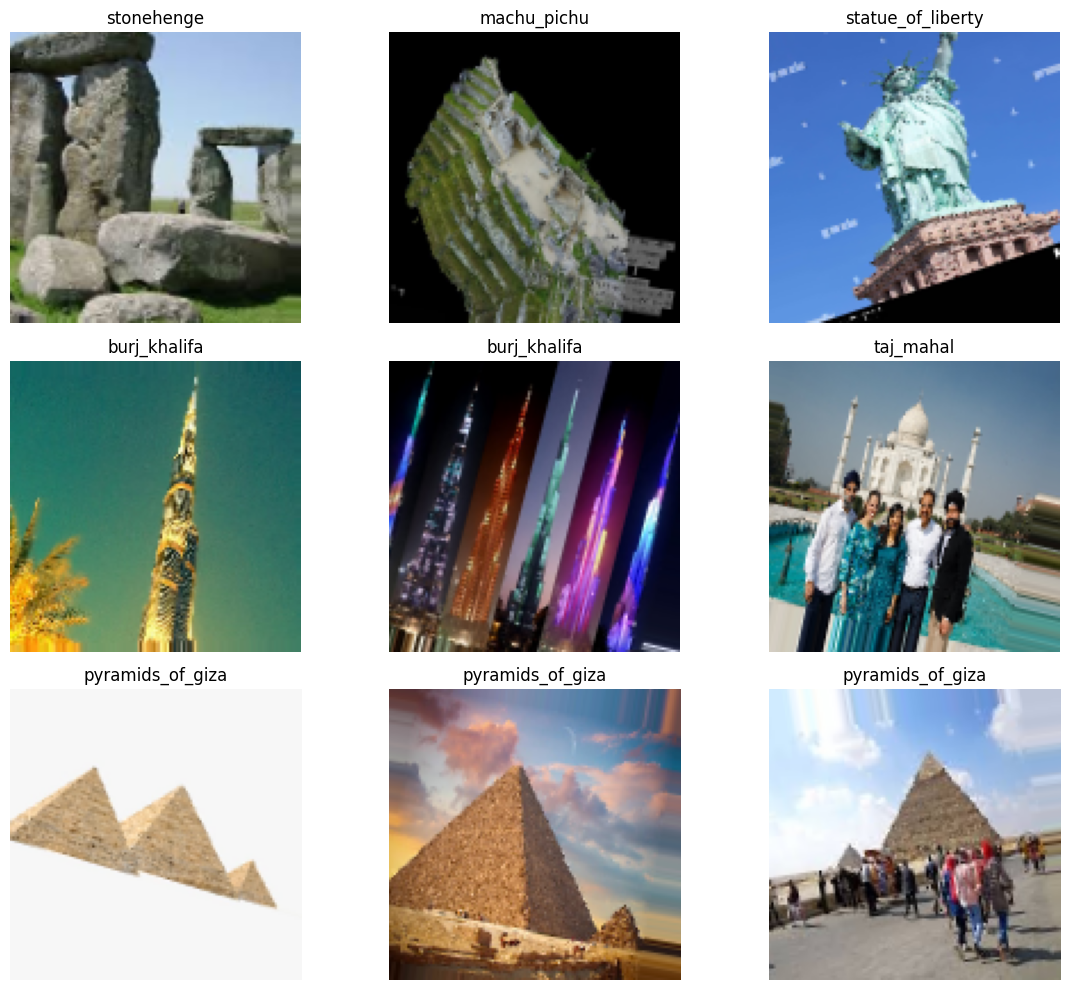

In [ ]:
def show_sample_images(generator, class_indices, num_images=9):
    images, labels = next(generator)
    class_names = list(class_indices.keys())

    plt.figure(figsize=(12, 10))
    for i in range(min(num_images, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        label_idx = np.argmax(labels[i])
        plt.title(class_names[label_idx])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(train_gen, train_gen.class_indices)


In [ ]:
print("Classes found:", train_gen.class_indices)
print("Total classes:", len(train_gen.class_indices))


Classes found: {'burj_khalifa': 0, 'chichen_itza': 1, 'christ_the_reedemer': 2, 'eiffel_tower': 3, 'great_wall_of_china': 4, 'machu_pichu': 5, 'pyramids_of_giza': 6, 'roman_colosseum': 7, 'statue_of_liberty': 8, 'stonehenge': 9, 'taj_mahal': 10, 'venezuela_angel_falls': 11}
Total classes: 12


In [ ]:
from pathlib import Path

train_dir = Path(r"D:\python\data\wonders_split\train")
for cls in train_dir.iterdir():
    print(cls.name, "→", len(list(cls.glob("*"))), "images")


burj_khalifa → 312 images
chichen_itza → 272 images
christ_the_reedemer → 258 images
eiffel_tower → 312 images
great_wall_of_china → 313 images
machu_pichu → 314 images
pyramids_of_giza → 297 images
roman_colosseum → 315 images
statue_of_liberty → 190 images
stonehenge → 163 images
taj_mahal → 126 images
venezuela_angel_falls → 200 images


In [ ]:
train_gen = train_datagen.flow_from_directory(
    directory=str(WORK_DIR / "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    directory=str(WORK_DIR / "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print("Classes found:", train_gen.class_indices)
print("Total classes:", NUM_CLASSES)


Found 3072 images belonging to 12 classes.
Found 774 images belonging to 12 classes.
Classes found: {'burj_khalifa': 0, 'chichen_itza': 1, 'christ_the_reedemer': 2, 'eiffel_tower': 3, 'great_wall_of_china': 4, 'machu_pichu': 5, 'pyramids_of_giza': 6, 'roman_colosseum': 7, 'statue_of_liberty': 8, 'stonehenge': 9, 'taj_mahal': 10, 'venezuela_angel_falls': 11}
Total classes: 12


In [ ]:
model, history = train_and_evaluate(
    activation='relu',
    optimizer_name='adam',
    lr=1e-3,
    epochs=20,
    exp_name='relu_adam'
)

evaluate_model(model, history, train_gen.class_indices, test_gen, 'ReLU + Adam')


Epoch 1/20
96/96 - 193s - loss: 1.9155 - accuracy: 0.3760 - val_loss: 3.4871 - val_accuracy: 0.0633 - lr: 0.0010 - 193s/epoch - 2s/step
Epoch 2/20
96/96 - 167s - loss: 1.5220 - accuracy: 0.4945 - val_loss: 3.7166 - val_accuracy: 0.1783 - lr: 0.0010 - 167s/epoch - 2s/step
Epoch 3/20
